# SmoothGrad Noise Level

/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cpu
Model: resnet50
Target class: 242
Number of samples for SmoothGrad: 50

Generating SmoothGrad saliency maps with different noise levels...
   Generating SmoothGrad with stdev = 0.00...
      Time: 149.33s
   Generating SmoothGrad with stdev = 0.05...
      Time: 144.62s
   Generating SmoothGrad with stdev = 0.10...
      Time: 68.25s
   Generating SmoothGrad with stdev = 0.20...
      Time: 68.41s
   Generating SmoothGrad with stdev = 0.30...
      Time: 61.93s
   Generating SmoothGrad with stdev = 0.50...
      Time: 57.81s


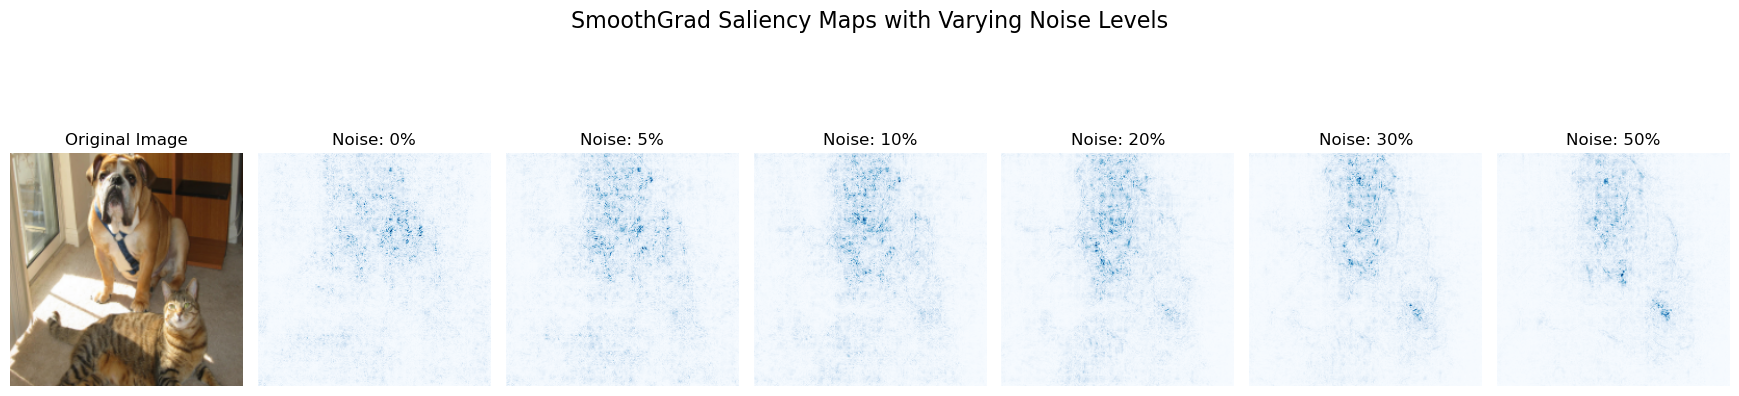

✅ Saved `smoothgrad_noise_level_recreation.pdf`


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import matplotlib.pyplot as plt
import requests
from PIL import Image
import numpy as np
import time

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'resnet50'
IMAGE_URL = 'https://raw.githubusercontent.com/utkuozbulak/pytorch-cnn-visualizations/master/input_images/cat_dog.png'
TARGET_CLASS = 242  # Boxer dog (ImageNet class index)
N_SAMPLES = 50  # For SmoothGrad

# 1. Load pre-trained model
def load_model(name):
    model_class = models.__dict__[name]
    try:
        weights = model_class.Weights.DEFAULT
        model = model_class(weights=weights)
    except AttributeError:
        model = model_class(pretrained=True)
    return model

model = load_model(MODEL_NAME)
model = model.to(DEVICE).eval()

# 2. Image preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Download and preprocess image
print("Downloading image...")
response = requests.get(IMAGE_URL, stream=True)
img = Image.open(response.raw)
input_tensor = preprocess(img).unsqueeze(0).to(DEVICE)
input_tensor.requires_grad = True

# Denormalization helper
def denorm(img_tensor):
    img = img_tensor.squeeze(0).permute(1,2,0).cpu().detach().numpy()
    return np.clip(
        img * np.array([0.229,0.224,0.225]) +
        np.array([0.485,0.456,0.406]),
        0,1
    )

# SmoothGrad function with stdev as a parameter
def generate_smoothgrad(stdev):
    total_gradients = torch.zeros_like(input_tensor)
    
    for _ in range(N_SAMPLES):
        noise = torch.normal(0, stdev, size=input_tensor.shape).to(DEVICE)
        noisy_input = (input_tensor.data + noise).detach().requires_grad_(True)
        
        output = model(noisy_input)
        target_score = output[0, TARGET_CLASS]
        
        model.zero_grad()
        target_score.backward()
        
        total_gradients += noisy_input.grad.data
    
    avg_gradients = total_gradients / N_SAMPLES
    gradients = avg_gradients[0]
    saliency = gradients.abs().max(dim=0)[0]
    return saliency

# Main execution for recreating the figure
if __name__ == '__main__':
    print(f"Using device: {DEVICE}")
    print(f"Model: {MODEL_NAME}")
    print(f"Target class: {TARGET_CLASS}")
    print(f"Number of samples for SmoothGrad: {N_SAMPLES}")

    # Define various standard deviation values to test
    # These values are chosen to represent 0%, 5%, 10%, 20%, 30%, 50% of the input range
    # Assuming input pixel values roughly normalized to [0, 1], so stdev can be percentages.
    # The original normalization makes the effective input range different.
    # A common heuristic for bandwidth (stdev) is 10-20% of the feature range.
    # Let's approximate the feature range for a normalized image.
    # The std of the normalized image is ~0.2-0.25. So 10-50% of that range would be reasonable.
    
    # We will use stdev values directly, and the user provided text suggests 10-20% bandwidth.
    # The 'Noise level' in Figure 4.8 likely refers to the standard deviation relative to the input feature range.
    # For a normalized image with mean ~0.5 and std ~0.2, a 10% bandwidth could be 0.02.
    # Let's use absolute standard deviations for demonstration, mimicking the noise levels in the image.
    # These values are chosen to show the effect, you might need to tune them based on your specific model/image.
    stdev_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5] # Corresponds to 0%, 5%, 10%, 20%, 30%, 50% noise level
    
    smoothgrad_explanations = []
    
    print("\nGenerating SmoothGrad saliency maps with different noise levels...")
    for stdev in stdev_values:
        print(f"   Generating SmoothGrad with stdev = {stdev:.2f}...")
        start = time.time()
        saliency_map = generate_smoothgrad(stdev)
        smoothgrad_explanations.append(saliency_map)
        print(f"      Time: {time.time()-start:.2f}s")
    
    # Recreate the figure layout
    n_stdev = len(stdev_values)
    
    fig, axs = plt.subplots(1, n_stdev + 1, figsize=(2.5 * (n_stdev + 1), 5)) # Adjusted for horizontal layout
    
    # Original image in the first column
    axs[0].imshow(denorm(input_tensor))
    axs[0].set_title('Original Image')
    axs[0].axis('off')
    
    # SmoothGrad saliency maps for different noise levels
    for i, (stdev, saliency) in enumerate(zip(stdev_values, smoothgrad_explanations)):
        amap = saliency.cpu().detach().numpy()
        amap = (amap - amap.min()) / (amap.max() - amap.min() + 1e-8) # Normalize to [0,1]
        
        axs[i+1].imshow(amap, cmap='Blues', vmin=0, vmax=1) # White-to-blue colormap
        axs[i+1].set_title(f'Noise: {int(stdev*100)}%')
        axs[i+1].axis('off')

    plt.tight_layout()
    plt.suptitle("SmoothGrad Saliency Maps with Varying Noise Levels", y=1.02, fontsize=16)
    plt.savefig('smoothgrad_noise_level_recreation.pdf')
    plt.show()
    print("✅ Saved `results/smoothgrad_noise_level_recreation.pdf`")